1.Importing the Dependencies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Setting up visual style
sns.set(style="whitegrid")

2.Data Cleaning

In [ ]:
# Load the dataset
df = pd.read_csv('chronic_disease_prediction_dataset.csv')

# Drop Patient_ID as it doesn't contribute to prediction
df.drop('Patient_ID', axis=1, inplace=True)

# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Encoding Categorical Variables to Numeric
label_enc = LabelEncoder()
categorical_cols = ['Gender', 'Smoking', 'AlcoholIntake', 'DietQuality', 'FamilyHistory', 'HasChronicDisease']

for col in categorical_cols:
    df[col] = label_enc.fit_transform(df[col])

print("\nData after cleaning and encoding:")
print(df.head())

Missing Values:
 Age                  0
Gender               0
BMI                  0
Smoking              0
AlcoholIntake        0
PhysicalActivity     0
DietQuality          0
SleepHours           0
BloodPressure        0
Cholesterol          0
Glucose              0
FamilyHistory        0
StressLevel          0
HasChronicDisease    0
dtype: int64

Data after cleaning and encoding:
   Age  Gender   BMI  Smoking  AlcoholIntake  PhysicalActivity  DietQuality  \
0   69       0  20.7        0              2               3.9            0   
1   32       1  30.0        0              2               0.7            2   
2   89       2  31.4        0              2               3.3            1   
3   78       1  24.7        0              0               3.7            0   
4   38       1  24.6        0              2               5.6            0   

   SleepHours  BloodPressure  Cholesterol  Glucose  FamilyHistory  \
0         6.7            110          215      171              1   


3.Data Visualization

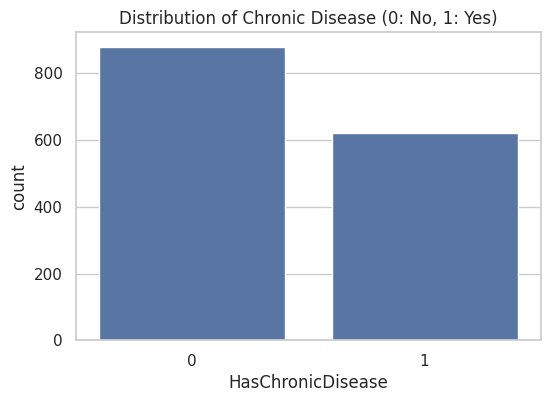

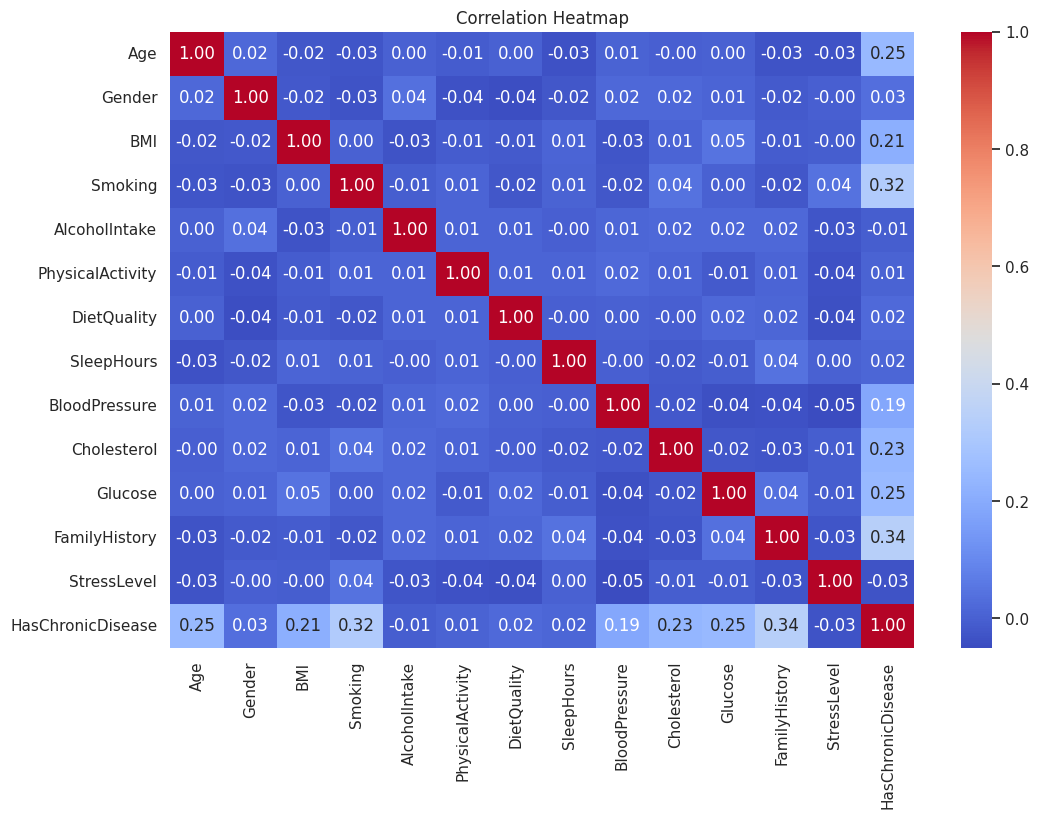

In [ ]:
# Plotting the distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='HasChronicDisease', data=df)
plt.title('Distribution of Chronic Disease (0: No, 1: Yes)')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

4.Exploratory Data Analysis (EDA)

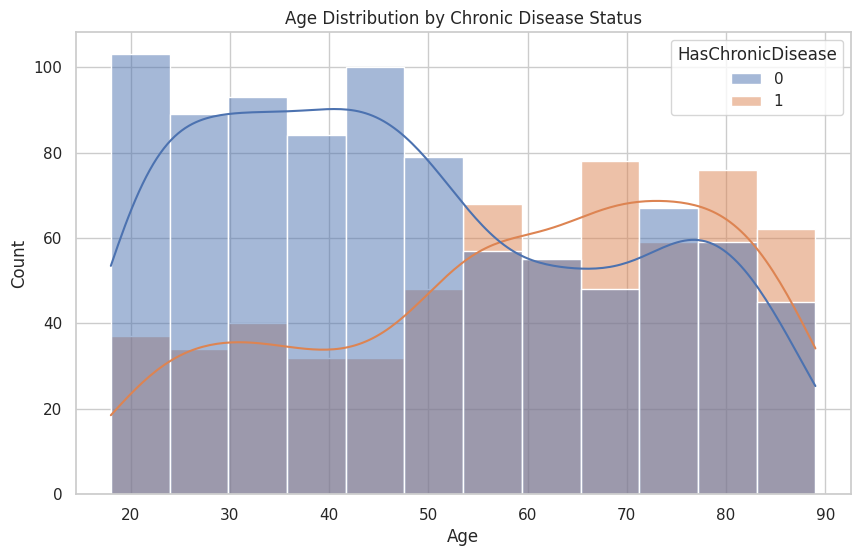

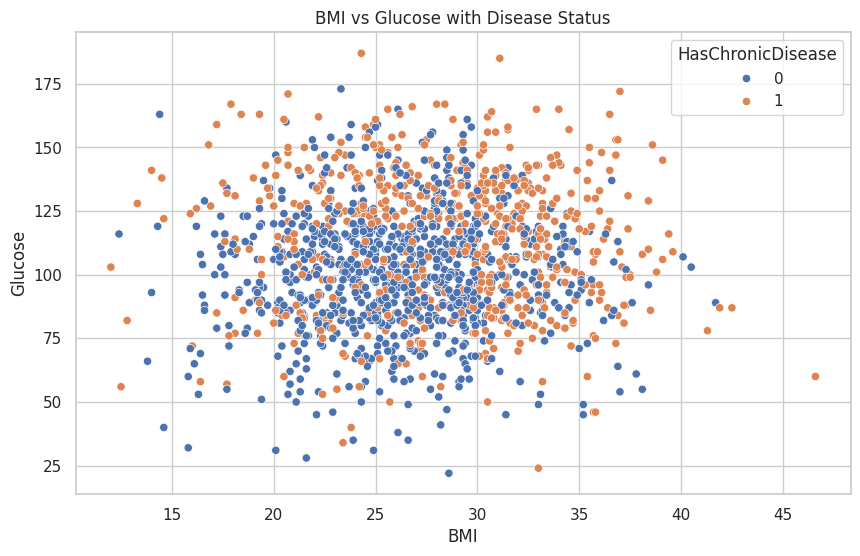

In [ ]:
# Age vs Chronic Disease
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='HasChronicDisease', kde=True)
plt.title('Age Distribution by Chronic Disease Status')
plt.show()

# BMI vs Glucose level
plt.figure(figsize=(10, 6))
sns.scatterplot(x='BMI', y='Glucose', hue='HasChronicDisease', data=df)
plt.title('BMI vs Glucose with Disease Status')
plt.show()

5.Data Modeling - Splitting the data into features and targets

In [ ]:
# X contains independent variables, y contains the target variable
X = df.drop('HasChronicDisease', axis=1)
y = df['HasChronicDisease']

6.Splitting the data into test and training data

In [ ]:
# 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

7.Model Training

In [ ]:
# Initialize the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Training the model
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

8.Model Evaluation

In [ ]:
# Making predictions
y_pred = model.predict(X_test)

# Checking accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Detailed Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 96.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       167
           1       0.98      0.92      0.95       133

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300



9.Communication and Visualization (Feature Importance)

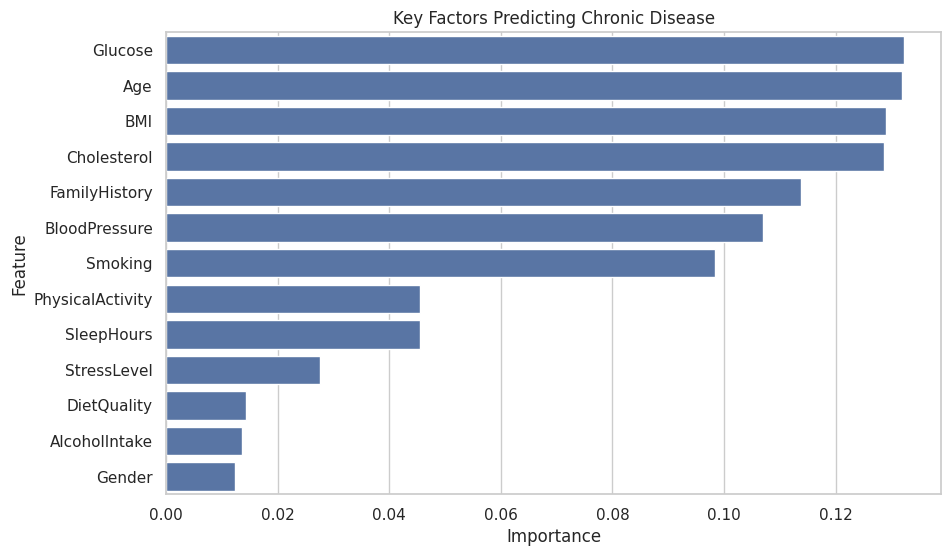

In [ ]:
# Visualizing Feature Importance
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Key Factors Predicting Chronic Disease')
plt.show()

10.Model Saving

In [ ]:
import pickle
# Even if you save as .sav, it uses the same pickle process
with open('chronic_model.sav', 'wb') as f:
    pickle.dump(model, f)